Call or Put ?  call
European or American ?  european
Spot :  100
Strike :  100
Volatility :  0.4
Maturity :  1
Risk Free Rate :  0.02


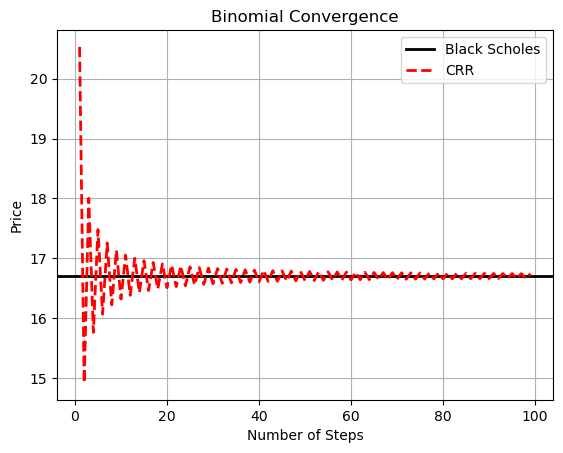

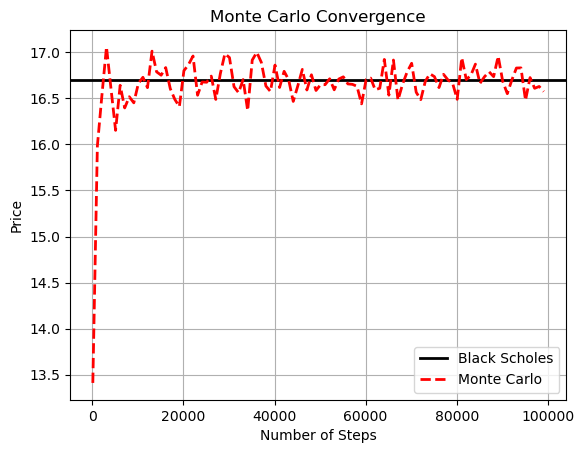

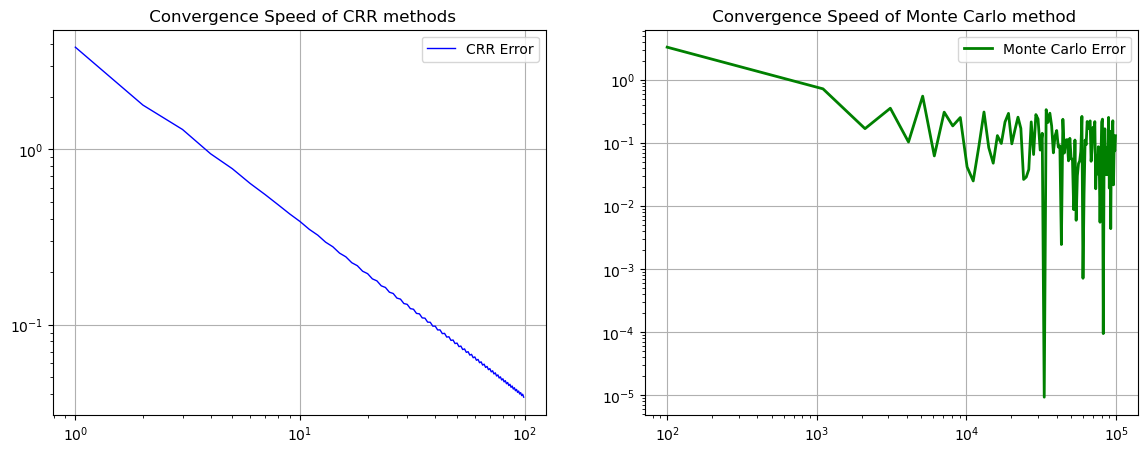

In [26]:
import matplotlib.pyplot as plt 
import numpy as np
from Option_Contract import OptionContract
from Black_Scholes import bs_price
from Binomial_Tree import crr_price
from Monte_Carlo_Options import mc_price 

%run Option_Contract.py
%run Black_Scholes.py
%run Binomial_Tree.py
%run Monte_Carlo_Options.py 

option = OptionContract(
    opt_type=input("Call or Put ? "),
    obs_type=input("European or American ? "),
    spot=float(input("Spot : ")),
    strike=float(input("Strike : ")),
    sigma=float(input("Volatility : ")),
    maturity=float(input("Maturity : ")),
    risk_free=float(input("Risk Free Rate : "))
)

nb_values = np.arange(1,100,1)
bs_value = bs_price(option)
crr_mat = [crr_price(option, n) for n in nb_values]

plt.axhline(y = bs_value, color = "black", linewidth = 2, label = "Black Scholes")
plt.plot(nb_values, crr_mat, color="red", linewidth=2, linestyle = "--", label="CRR")
plt.title("Binomial Convergence")
plt.xlabel("Number of Steps")
plt.ylabel("Price")
plt.grid()
plt.legend()
plt.show()

nb_sim = np.arange(100, 100000, 1000)

mc_mat = [mc_price(option, n) for n in nb_sim]
plt.axhline(y=bs_value, color = "black", linewidth = 2, label = "Black Scholes")
plt.plot(nb_sim, mc_mat, color = "red", linewidth = 2, linestyle = "--", label = "Monte Carlo")
plt.title("Monte Carlo Convergence")
plt.xlabel("Number of Steps")
plt.ylabel("Price")
plt.grid()
plt.legend()
plt.show()


crr_error = np.abs(np.array(crr_mat)-bs_value)
mc_error = np.abs(np.array(mc_mat)-bs_value)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(nb_values, crr_error, label = "CRR Error", color = "blue", linewidth=1)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_title(" Convergence Speed of CRR methods")
ax1.legend()
ax1.grid()


ax2.plot(nb_sim,mc_error, label= "Monte Carlo Error", color = "green", linewidth = 2)
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_title(" Convergence Speed of Monte Carlo method")
ax2.legend()
ax2.grid()
plt.show()

